In [56]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Load Data mia grammi psaksto 
n_0 = np.loadtxt("n_0.txt")
freq = n_0[:, 0]
n_real = n_0[:, 1]
n_imag= n_0[:, 2]
n = n_real + 1j * n_imag

#cut zero frequency because no convergence
mask = freq >= 0.1e12
freq = freq[mask]
n_real= n_real[mask]
n_imag= n_imag[mask]
n = n[mask]

# constants
L = 2e-3  
c = 3e8  

# add noise
H_th = (4 * n) / ((1 + n) ** 2) * np.exp(-1j * L * 2 * np.pi * freq * (n - 1) / c)
H_exp = (np.abs(H_th) + np.random.normal(0, 0.3, len(H_th))) * np.exp(1j * (np.angle(H_th) + np.random.normal(0, 0.3, len(H_th))))
#H_exp=np.random.normal(0,0.3,len(H_th))+H_th

#move to torch
freq_t = torch.tensor(freq, dtype=torch.float32)
H_exp_t = torch.tensor(H_exp, dtype=torch.complex64)
n_real_t = torch.tensor(n_real, dtype=torch.float32)
n_imag_t = torch.tensor(n_imag, dtype=torch.float32)

#H_theoretical  with torch
def H_th_t(n, freq):
    return (4 * n) / ((1 + n) ** 2) * torch.exp(-1j * L * 2 * torch.pi * freq * (n - 1) / c)

# loss function
def loss_function(H_proposed, H_exp):
    return (torch.real(H_proposed) - torch.real(H_exp)) ** 2 +(torch.imag(H_proposed) - torch.imag(H_exp)) ** 2

# optimization function 
def optimize(freq, H_exp, n_real_init, n_imag_init, lr=0.001, max_iterations=500, tol=1e-5, patience=5):
    n_opt = torch.zeros_like(n_real_init) # create tensors with length of n_init full of zeros 
    k_opt = torch.zeros_like(n_imag_init)

    # only the first guess comes from  n_0.txt
    n_real_proposed = n_real_init[0].clone().detach().requires_grad_(True)
    n_imag_proposed = n_imag_init[0].clone().detach().requires_grad_(True)

    for i in range(len(freq)):
        f = freq[i]
        H_exp_f = H_exp[i]

       #after first guess all others are the previous optimized ones
        if i > 0:
            n_real_proposed = n_opt[i-1].clone().detach().requires_grad_(True)
            n_imag_proposed = k_opt[i-1].clone().detach().requires_grad_(True)

        optimizer = torch.optim.Adam([n_real_proposed, n_imag_proposed], lr=lr)
        best_loss = float("inf")
        patience_counter = 0

        for step in range(max_iterations):
            optimizer.zero_grad()
            n_complex = n_real_proposed + 1j * n_imag_proposed

            f_t = torch.tensor([f], dtype=torch.float32)

            H_pred = H_th_t(n_complex, f_t) #calling the H theoretical torch function with n_complex and f_t
            loss = loss_function(H_pred, H_exp_f) #calling the loss function 
            loss.backward()
            optimizer.step()

            # break early if 
            if abs(best_loss - loss.item()) < tol:
                patience_counter += 1 #add to patience if no improvement bigger than 1e-5
            else:
                patience_counter = 0  #reset if improvement

            if patience_counter >= patience:  
                break

            best_loss = loss.item()

       
        n_opt[i] = n_real_proposed.detach() #save the optimized values
        k_opt[i] = n_imag_proposed.detach()

    return n_opt, k_opt

# calling the optimization function
n_opt, k_opt = optimize(freq_t, H_exp_t,n_t , k_t)

# calculate optimized H
H_opt = H_th_t(n_opt + 1j * k_opt, freq_t).detach().numpy()



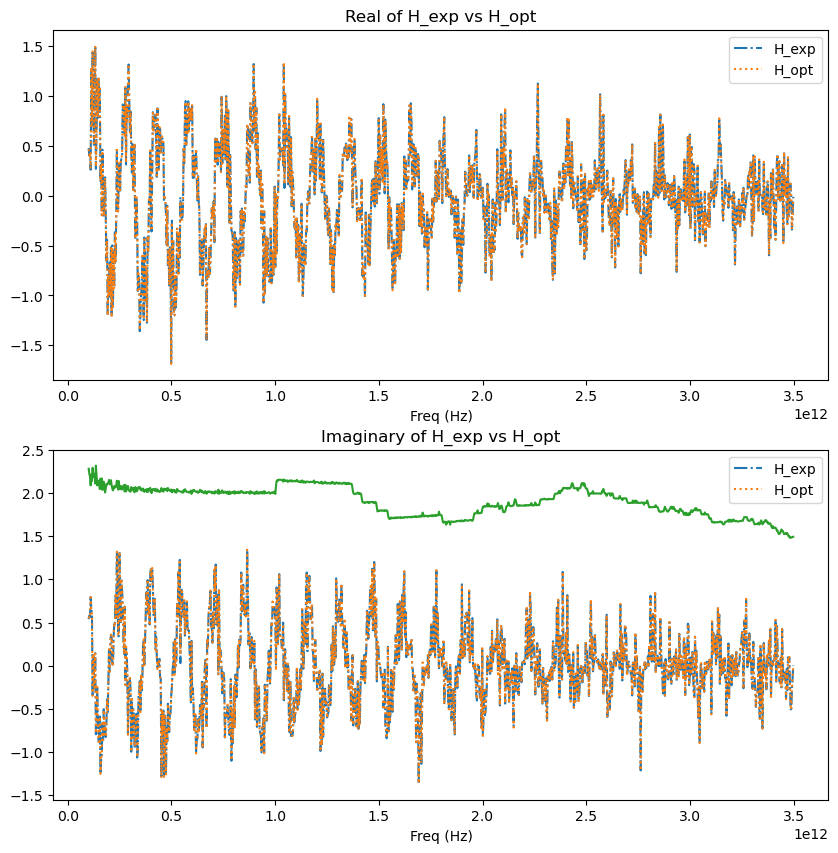

In [57]:
# plot 
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
plt.plot(freq, np.real(H_exp), label="H_exp", linestyle="-.")
plt.plot(freq, np.real(H_opt), label="H_opt", linestyle=":")
plt.legend()
plt.xlabel("Freq (Hz)")
plt.title("Real of H_exp vs H_opt")

plt.subplot(2, 1, 2)
plt.plot(freq, np.imag(H_exp), label="H_exp", linestyle="-.")
plt.plot(freq, np.imag(H_opt), label="H_opt", linestyle=":")
plt.legend()
plt.xlabel("Freq (Hz)")
plt.title("Imaginary of H_exp vs H_opt")

plt.plot(freq,n_opt)
plt.show()